# Import Library

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import collections
import nltk
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import ngrams
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load Dataset

In [2]:
data = pd.read_csv(r'/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv', sep=',', encoding='utf-8')
data.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
data.shape   # CHECK THE DIMENSION OF DATASET

(50000, 2)

In [4]:
# DISPLAY SOME REVIEWS
for i in range(1,4):
    print(f'Reviews   : {data.loc[i, "review"]}')
    print(f'Sentiment : {data.loc[i, "sentiment"]}\n')

Reviews   : A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly 

# Preprocessing

## Check Missing Values

In [5]:
data.isna().sum()

review       0
sentiment    0
dtype: int64

there's no missing values

## Handling Duplicate Data

In [6]:
data.duplicated(subset='review').sum()

418

there's some duplicated data, lets drop it

In [7]:
# DROP ALL DUPLICATE DATA
data.drop_duplicates(subset='review', inplace=True)

# AFTER DROPPED
data.shape

(49582, 2)

## Remove HTML Tag

In [8]:
# REMOVE HTML TAG

clean_data = []

# ITERATE OVER EACH REVIEW SAMPLE
for review in data['review']:

    soup = BeautifulSoup(review, 'html.parser')  # DEFINE BEAUTIFUL SOUP
    text = soup.get_text()     # GET ONLY TEXT FROM BEAUTIFULSOUP
    clean_data.append(text)

# DISPLAY INFORMATION
print(f'Before BeautifulSoup : {data.loc[1, "review"]}\n')
print(f'After BeautifulSoup  : {clean_data[1]}')

<ipython-input-8-9d02116ff788>:8: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(review, 'html.parser')  # DEFINE BEAUTIFUL SOUP


Before BeautifulSoup : A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) ar

## Remove Stopwords

In [9]:

# CONVERT TO LOWERCASE
reviews = [review.lower() for review in clean_data]

# DEFINE STOPWORDS
stop_words = stopwords.words('english')

clean_data = []

# ITERATE OVER LIST OF STRINGS TO REMOVE A STOPWORDS
for review in reviews:

    # GET ALL WORD THAT ARE NOT A STOPWORDS
    clean_text = [word for word in review.split() if word not in stop_words]
    clean_text = ' '.join(clean_text)   # COMBINES EVERY WORD INTO SENTENCES

    clean_data.append(clean_text)   # PUSH EVERY REVIEW INTO LIST

# DISPLAY 
print(f'Before Removing Stopwords : {reviews[0]}\n')
print(f'After Removing Stopwords  : {clean_data[0]}')


Before Removing Stopwords : one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that i

## Lemmatization

In [10]:
# DEBUGGING

import os
from zipfile import ZipFile

# DOWNLOAD LEMMATIZER FILE
nltk.download('wordnet', download_dir='/root/nltk_data')

# CREATE NEW DIRECTORY
os.makedirs('/root/nltk_data/corpora', exist_ok=True)

# ADD PATH NLTK
nltk.data.path.append('/root/nltk_data')

# EXTRACT-IT
with ZipFile('/root/nltk_data/corpora/wordnet.zip', 'r') as zip_ref:
    zip_ref.extractall('/root/nltk_data/corpora')

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [11]:
# LEMMATIZATION

lemma = WordNetLemmatizer()

lemmatized_data = []

# ITERATE OVER LIST OF STRINGS TO LEMMATIZE 
for review in clean_data:

    # LEMMATIZE ADJECTIVES TOKEN/WORD
    clean_text_1 = [lemma.lemmatize(word= word, pos='a') for word in review.split()]  
    clean_text_1 = ' '.join(clean_text_1)  # COMBINES EVERY WORD INTO SENTENCES

    # LEMMATIZE VERB TOKEN/WORD
    clean_text_2 = [lemma.lemmatize(word = word, pos='v') for word in clean_text_1.split()] 
    clean_text_2 = ' '.join(clean_text_2) # COMBINES EVERY WORD INTO SENTENCES

    # LEMMATIZE NOUN TOKEN/WORD
    clean_text_3 = [lemma.lemmatize(word= word, pos='n') for word in clean_text_2.split()] 
    clean_text_3 = ' '.join(clean_text_3)

    lemmatized_data.append(clean_text_3) 

# DISPLAY
for i in range(5):
    print(f'Before Lemmatize : {clean_data[i]}\n')
    print(f'After Lemmatize  : {lemmatized_data[i]}')

Before Lemmatize : one reviewers mentioned watching 1 oz episode hooked. right, exactly happened me.the first thing struck oz brutality unflinching scenes violence, set right word go. trust me, show faint hearted timid. show pulls punches regards drugs, sex violence. hardcore, classic use word.it called oz nickname given oswald maximum security state penitentary. focuses mainly emerald city, experimental section prison cells glass fronts face inwards, privacy high agenda. em city home many..aryans, muslims, gangstas, latinos, christians, italians, irish more....so scuffles, death stares, dodgy dealings shady agreements never far away.i would say main appeal show due fact goes shows dare. forget pretty pictures painted mainstream audiences, forget charm, forget romance...oz mess around. first episode ever saw struck nasty surreal, say ready it, watched more, developed taste oz, got accustomed high levels graphic violence. violence, injustice (crooked guards who'll sold nickel, inmates w

## Tokenization

In [12]:
# TOKENIZATION

new_data = []

# ITERATE OVER LIST OF STRINGS TO TOKENIZE EVERY REVIEW
for review in lemmatized_data:

    # TOKENIZE EVERY REVIEW
    text = word_tokenize(text= review, language='english', preserve_line= False)
    new_data.append(text)

# DISPLAY
print(f'Before Tokenization : {lemmatized_data[0]}\n')
print(f'After Tokenization  : {new_data[0]}')

Before Tokenization : one reviewer mention watch 1 oz episode hooked. right, exactly happen me.the first thing strike oz brutality unflinching scene violence, set right word go. trust me, show faint hearted timid. show pull punch regard drugs, sex violence. hardcore, classic use word.it call oz nickname give oswald maximum security state penitentary. focus mainly emerald city, experimental section prison cell glass front face inwards, privacy high agenda. em city home many..aryans, muslims, gangstas, latinos, christians, italians, irish more....so scuffles, death stares, dodgy deal shady agreement never far away.i would say main appeal show due fact go show dare. forget pretty picture paint mainstream audiences, forget charm, forget romance...oz mess around. first episode ever saw strike nasty surreal, say ready it, watch more, develop taste oz, get accustom high level graphic violence. violence, injustice (crooked guard who'll sell nickel, inmate who'll kill order get away it, well ma

## Remove Punctuation

In [13]:
# REMOVE PUNCTUATION

import re

final_data = []

# REMOVE ALL PUNCTUATION USING REGEX
for review in new_data:             # ITERATE OVER LIST OF STRINGS

    cleaned_token = []

    # ITERATE OVER EVERY TOKEN
    for token in review:
        clean_token = re.sub(pattern= r'[^\w\s]', repl= '', string= token)  # REPLACE ALL PUNCTUATION INTO EMPTY STRING ''

        # PUSH NON EMPTY STRINGS AND REMOVE CHARACTERS THAT HAVE ONLY 1
        if len(clean_token) > 1 :
            cleaned_token.append(clean_token)

    final_data.append(cleaned_token)  # PUSH CLEANED REVIEWS

# DISPLAY
for i in range(3):
    print(f'Before Remove Punctuation : {new_data[i]}\n')
    print(f'After Remove Punctuation  : {final_data[i]}\n')

Before Remove Punctuation : ['one', 'reviewer', 'mention', 'watch', '1', 'oz', 'episode', 'hooked', '.', 'right', ',', 'exactly', 'happen', 'me.the', 'first', 'thing', 'strike', 'oz', 'brutality', 'unflinching', 'scene', 'violence', ',', 'set', 'right', 'word', 'go', '.', 'trust', 'me', ',', 'show', 'faint', 'hearted', 'timid', '.', 'show', 'pull', 'punch', 'regard', 'drugs', ',', 'sex', 'violence', '.', 'hardcore', ',', 'classic', 'use', 'word.it', 'call', 'oz', 'nickname', 'give', 'oswald', 'maximum', 'security', 'state', 'penitentary', '.', 'focus', 'mainly', 'emerald', 'city', ',', 'experimental', 'section', 'prison', 'cell', 'glass', 'front', 'face', 'inwards', ',', 'privacy', 'high', 'agenda', '.', 'em', 'city', 'home', 'many..aryans', ',', 'muslims', ',', 'gangstas', ',', 'latinos', ',', 'christians', ',', 'italians', ',', 'irish', 'more', '...', '.so', 'scuffles', ',', 'death', 'stares', ',', 'dodgy', 'deal', 'shady', 'agreement', 'never', 'far', 'away.i', 'would', 'say', 'main

# Exploratory Data Analysis

## Check Distribution

In [14]:
print(f'There are {len(final_data)} samples')
print(f'Type : {type(final_data)}')

There are 49582 samples
Type : <class 'list'>


In [15]:
# COUNT TOTAL OF UNIQUE WORDS

unique_words = set()

# ITERATE OVER LIST OF STRING
for review in final_data:

    # ITERATE EVERY WORD IN A SENTENCE
    for word in review:
        unique_words.add(word)

print(f'number of unique words: {len(unique_words)}')

number of unique words: 179649


In [16]:
# SENTIMENT FREQUENCY

data['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

<Axes: xlabel='sentiment', ylabel='count'>

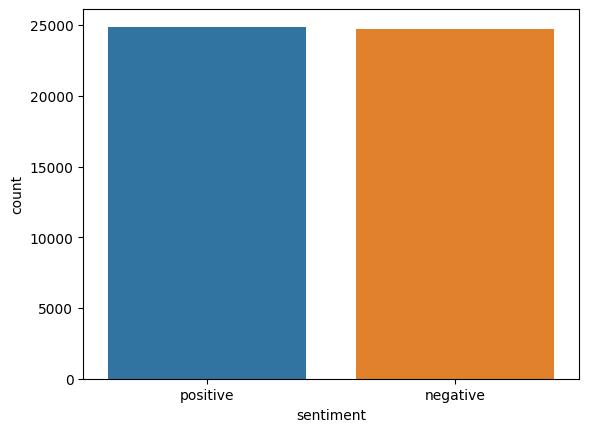

In [17]:
# PLOT IT

sns.countplot(data, x= 'sentiment')

the frequency between positive and negative is balanced

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Text Length Distribution')

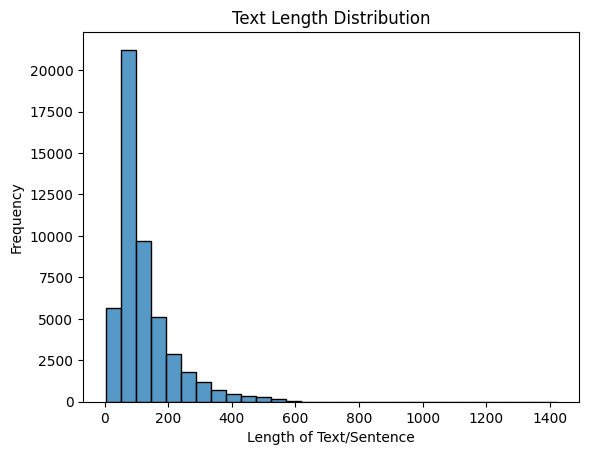

In [18]:
# TEXT/SENTENCE LENGTH DISTRIBUTION

# COUNT SENTENCE/TEXT LENGTH IN DATASET/DOCUMENT
length_text = [len(text) for text in final_data]

# DISPLAY VISUALIZE
sns.histplot(data= length_text, bins=30)
plt.xlabel('Length of Text/Sentence')
plt.ylabel('Frequency')

plt.title('Text Length Distribution')

## Bigrams and Trigrams

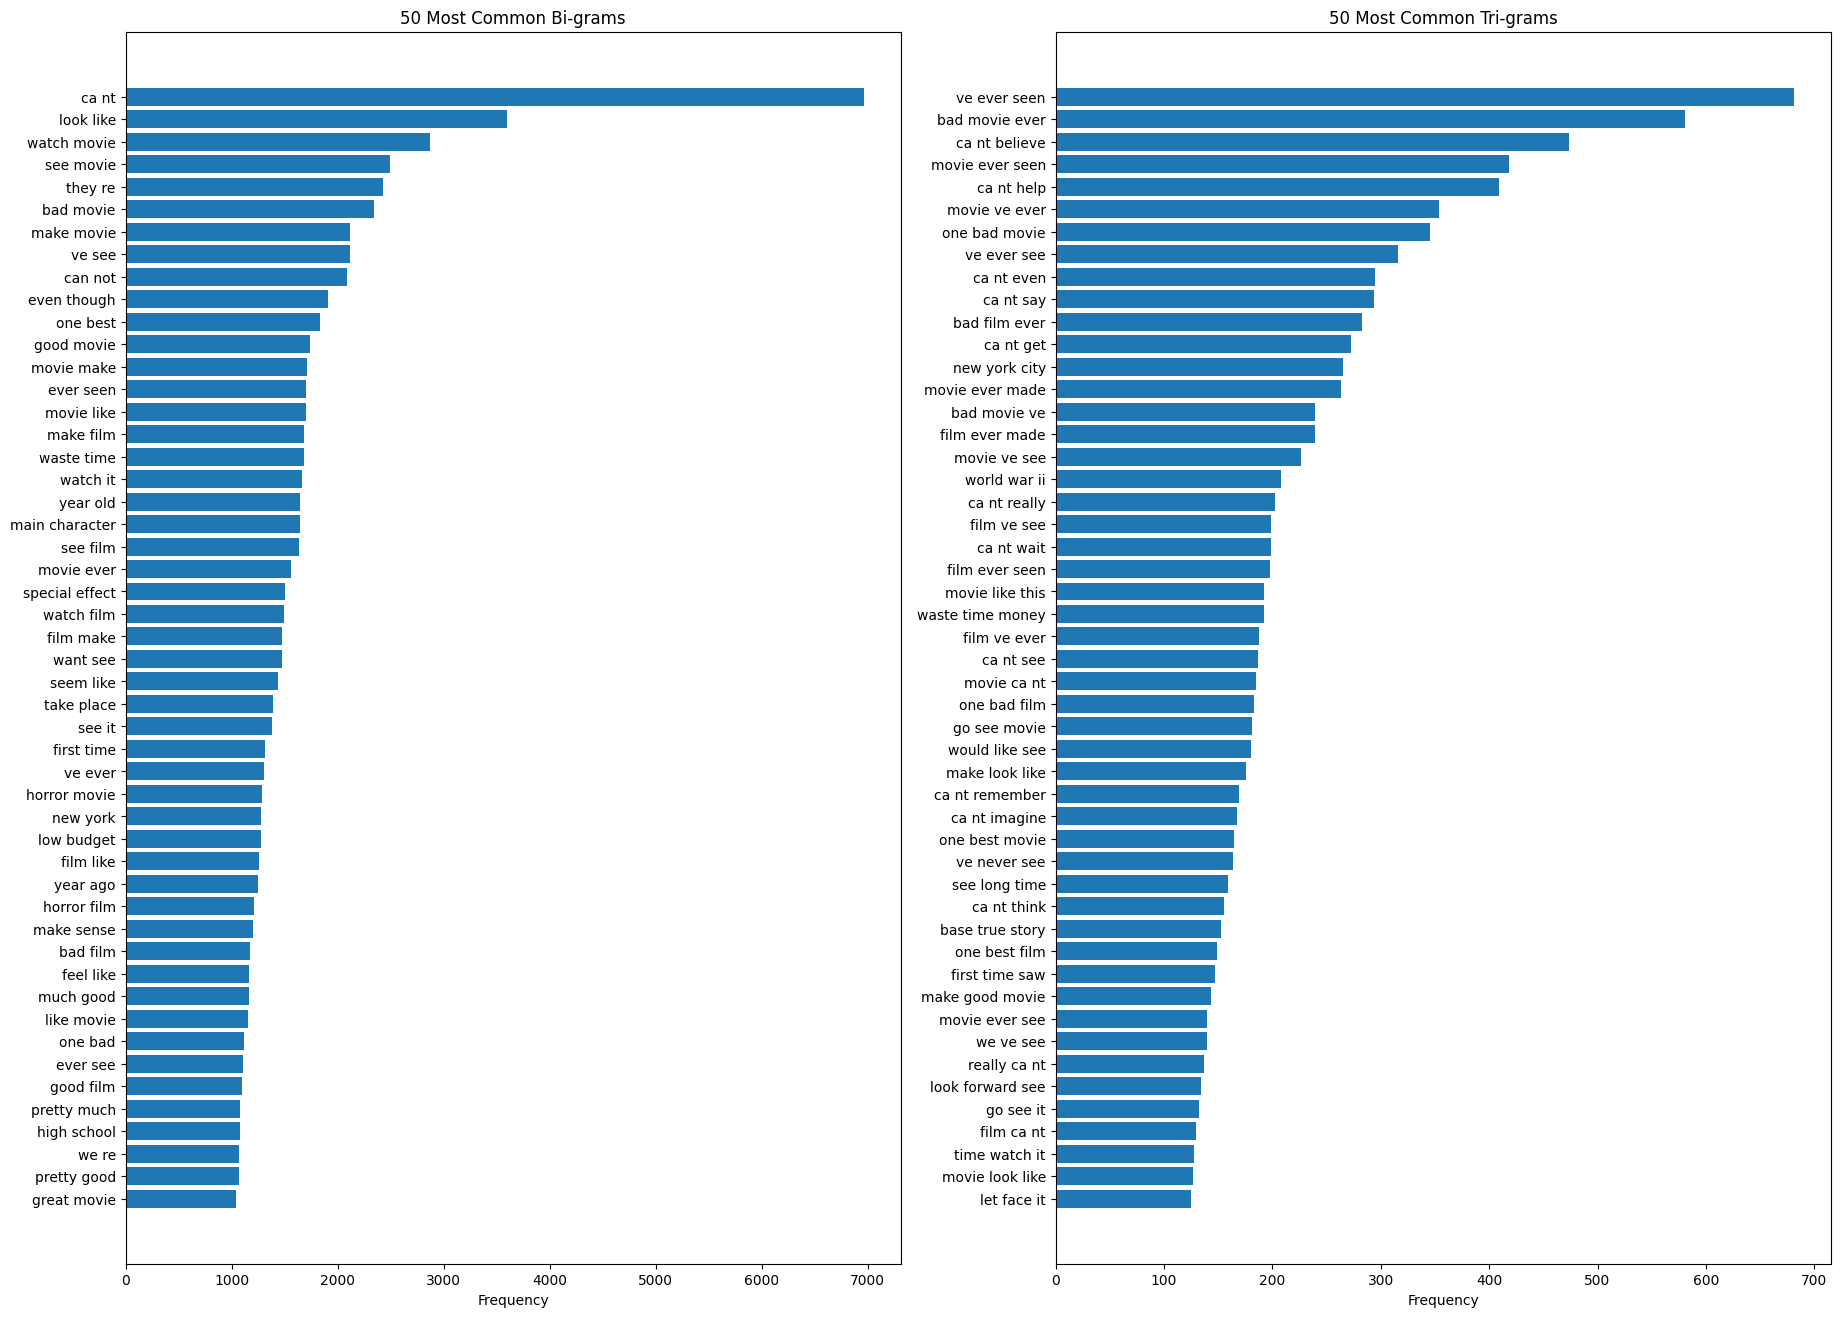

In [19]:

bigrams = []
trigrams = []


for review in final_data:

    # CREATE BI-GRAMS TUPLE
    bigrams.extend( ngrams(sequence= review, n= 2) )

    # CREATE TRI-GRAMS TUPLE
    trigrams.extend( ngrams(sequence= review, n= 3) )

# PUSH IT TO DICTIONARY
bigrams_freq  = collections.Counter(bigrams)
trigrams_freq = collections.Counter(trigrams)


# GET TOP 50
top_50_bigrams  = bigrams_freq.most_common(50)
top_50_trigrams = trigrams_freq.most_common(50)

# VISUALIZE BI-GRAMS
words, freqs  = zip(*top_50_bigrams)
words = [' '.join(bigram) for bigram in words]    # CONVERT BI-GRAMS TO LIST


  # BAR PLOT
plt.figure(figsize=(22,16))
plt.subplot(1,2,1)
plt.barh(words, freqs)

plt.xlabel('Frequency')
plt.title('50 Most Common Bi-grams')
plt.gca().invert_yaxis()      # SORT TO DESCENDING


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# VISUALIZE TRI-GRAMS
words, freqs  = zip(*top_50_trigrams)
words = [' '.join(trigram) for trigram in words]  # CONVERT TRI-GRAMS TO LIST

plt.subplot(1,2,2)
plt.barh(words, freqs)

plt.xlabel('Frequency')
plt.title('50 Most Common Tri-grams')
plt.gca().invert_yaxis()      # SORT TO DESCENDING

plt.show()

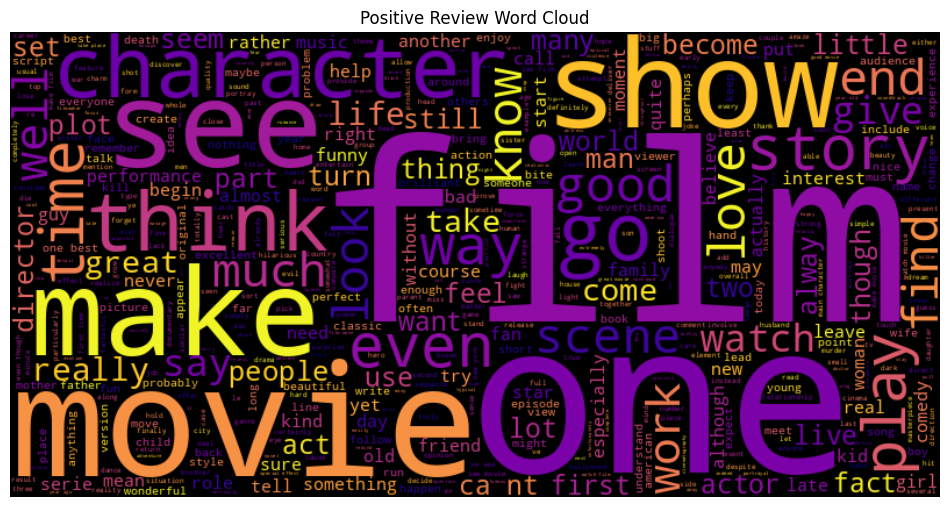

In [20]:
# WORD CLOUD FOR POSITIVE REVIEW


data = data.reset_index(drop=True)

# COMBINES ALL WORDS/TOKEN SINGLE STRING
positive_text = ' '.join(' '.join(str(word) for word in final_data[i]) for i in range(len(final_data)) if data.loc[i, 'sentiment'] == 'positive')

# CREATE WORDCLOUD
positive_cloud = WordCloud(stopwords= None, width=800, height=400, max_words= 500, colormap='plasma').generate(positive_text)

# DISPLAY VISUALIZE
plt.figure(figsize=(12,7))
plt.imshow(positive_cloud, interpolation='bilinear')
plt.title('Positive Review Word Cloud')
plt.axis('off')

plt.show()

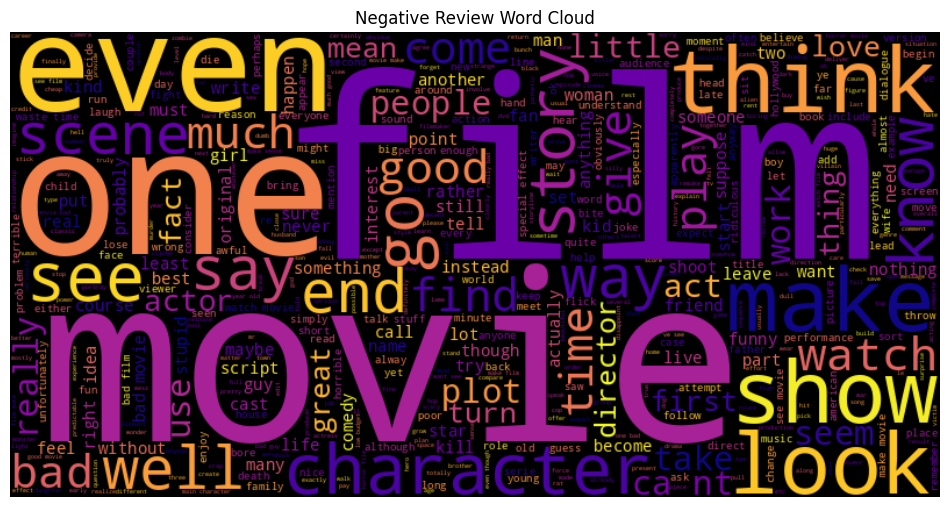

In [21]:
# WORD CLOUD FOR NEGATIVE REVIEW


data = data.reset_index(drop=True)

# COMBINES ALL WORDS/TOKEN SINGLE STRING
negative_text = ' '.join(' '.join(str(word) for word in final_data[i]) for i in range(len(final_data)) if data.loc[i, 'sentiment'] == 'negative')

# CREATE WORDCLOUD
negative_cloud = WordCloud(stopwords= None, width=800, height=400, max_words= 500, colormap='plasma').generate(negative_text)

# DISPLAY VISUALIZE
plt.figure(figsize=(12,7))
plt.imshow(negative_cloud, interpolation='bilinear')
plt.title('Negative Review Word Cloud')
plt.axis('off')

plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


Text(0, 0.5, 'Words')

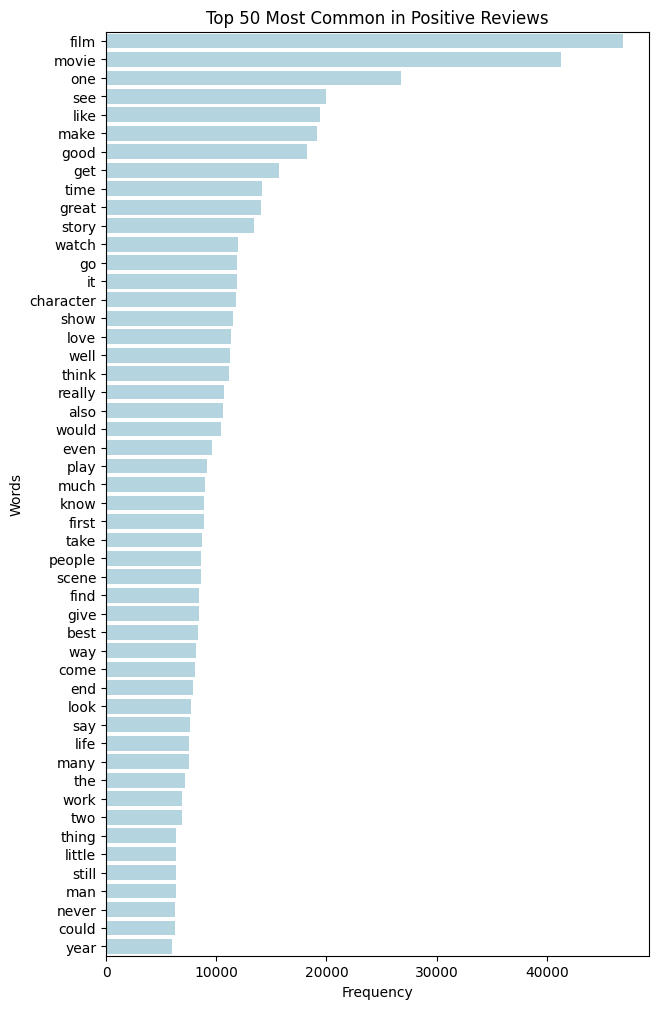

In [22]:
# MOST APPEAR WORDS IN POSITIVE REVIEWS

positive_reviews = []

# SELECT ONLY POSITIVE REVIEWS
for i in range(len(final_data)):

    if data.loc[i, 'sentiment'] == 'positive':
        positive_reviews.append(final_data[i])


positive_dict = {}   # DEFINE DICTIONARY

# CREATE HASH TABLE FOR POSITIVE REVIEWS
for review in positive_reviews:

    # ITERATE OVER TOKEN 
    for token in review:

        if token not in positive_dict:  # IF TOKEN IS NOT IN THE DICTIONARY
            positive_dict[token] = 1
        else:
            positive_dict[token] += 1  # IF TOKEN IS IN THE DICTIONARY


# GET TOP 50 POSITIVE WORDS
top_50_positive = dict( sorted(positive_dict.items(), key= lambda x: x[1], reverse= True)[:50] )

# CONVERT DICT TO LIST 
keys = list(top_50_positive.keys())
values = list(top_50_positive.values())

plt.figure(figsize=(7,12))

sns.barplot(x= values, y= keys, color='lightblue')
plt.title('Top 50 Most Common in Positive Reviews')
plt.xlabel('Frequency')
plt.ylabel('Words')


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


Text(0, 0.5, 'Words')

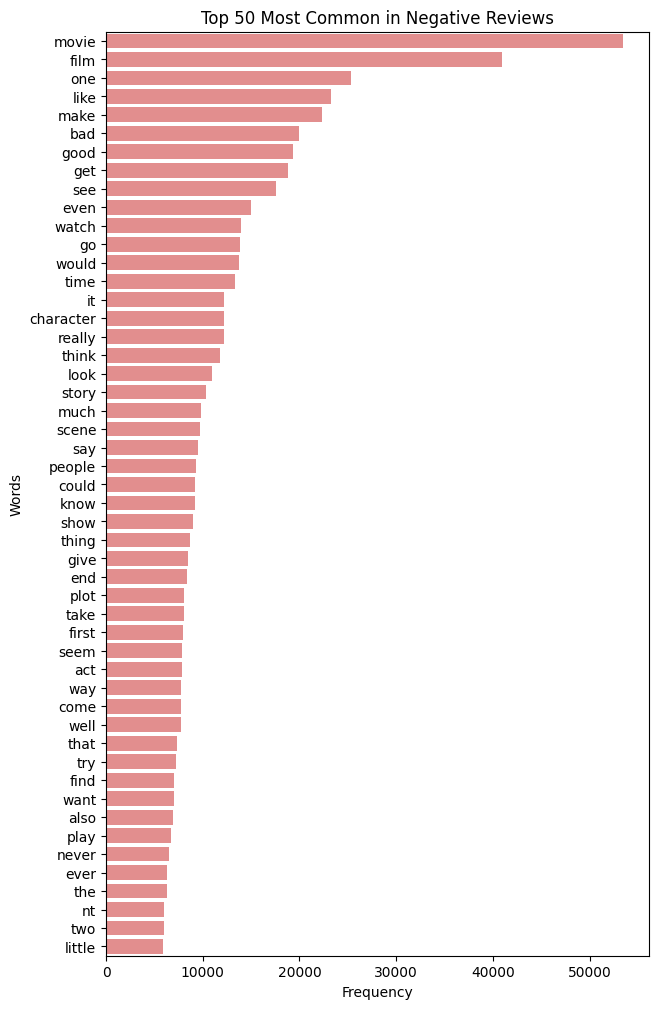

In [23]:
# MOST APPEAR WORDS IN NEGATIVE REVIEWS

negative_reviews = []

# SELECT ONLY NEGATIVE REVIEWS
for i in range(len(final_data)):
    if data.loc[i, 'sentiment'] == 'negative':  
        negative_reviews.append(final_data[i])


negative_dict = {}   # DEFINE DICTIONARY

# CREATE HASH TABLE FOR POSITIVE REVIEWS
for review in negative_reviews:

    # ITERATE OVER TOKEN 
    for token in review:

        if token not in negative_dict:  # IF TOKEN IS NOT IN THE DICTIONARY
            negative_dict[token] = 1
        else:
            negative_dict[token] += 1   # IF TOKEN IS IN THE DICTIONARY


# GET TOP 50 NEGATIVE WORDS
top_50_negative = dict( sorted(negative_dict.items(), key= lambda x: x[1], reverse= True)[:50] )

keys = list(top_50_negative.keys())
values = list(top_50_negative.values()) 

plt.figure(figsize=(7,12))

sns.barplot(x= values, y= keys, color='lightcoral')
plt.title('Top 50 Most Common in Negative Reviews')
plt.xlabel('Frequency')
plt.ylabel('Words')

## Post Tagging

In [24]:
# POST TAGGING

# DOWNLOAD RESOURCES
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

# CREATE NEW NLTK PATH
#nltk.data.path.append(r'C:\Users\aliff\AppData\Roaming\nltk_data\taggers')

flatten_data = []
# POST TAGGING NEED A DATA TO BE LIST OF TOKEN , SO WE FLATTEN-IT DATA 
for review in final_data:
    for token in review:
        flatten_data.append(token)

# FIT POST TAGGING
tagged = nltk.pos_tag(tokens=flatten_data)

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [25]:
# DISPLAY SOME RESULT POST-TAG
tagged[:10]

[('one', 'CD'),
 ('reviewer', 'JJR'),
 ('mention', 'NN'),
 ('watch', 'NN'),
 ('oz', 'NN'),
 ('episode', 'NN'),
 ('hooked', 'VBD'),
 ('right', 'RB'),
 ('exactly', 'RB'),
 ('happen', 'VB')]

In [26]:
# CHECK UNIQUE LABELS IN POST TAG

unique_labels = set()

for tuple in tagged:
    unique_labels.add(tuple[1])

print(f'Number of Unique Labels : {len(unique_labels)}')
print(f'Unique Labels           : {unique_labels}')

Number of Unique Labels : 37
Unique Labels           : {'WRB', 'JJ', 'NNS', 'IN', 'JJR', 'RP', 'UH', 'VBD', '$', 'JJS', 'CD', 'WDT', 'VBG', 'RBS', 'PDT', 'NNP', 'WP', 'VBP', 'RB', 'PRP$', "''", 'POS', 'EX', 'RBR', 'WP$', 'PRP', 'FW', 'VB', 'CC', 'NNPS', 'TO', '``', 'NN', 'VBN', 'VBZ', 'MD', 'DT'}


<pre style='font-family:Arial;'> Common POS Tags Explained 

1. <strong>$ : Dollar sign </strong> – Typically used to indicate a currency value.
Examples: $5, $100

2. <strong>IN: Preposition or subordinating conjunction </strong>– A word that connects a noun or noun phrase to another word.
Examples: "in," "on," "at," "with"

3. <strong> VBP: Verb, non-3rd person singular present </strong> – A verb in the present tense that isn't for 3rd-person singular subjects (like he, she, it).
Examples: "run," "eat" (for subjects other than "he," "she," or "it")

4. <strong> RBS: Adverb, superlative </strong> – An adverb in its superlative form, indicating the highest degree.
Examples: "most," "fastest"

5. <strong>'' and ``: Quotation marks </strong> – Used to indicate a quotation or direct speech or quotations.
Example: "Hello"

6. <strong>RP: Particle </strong>– A small word that often combines with a verb to form phrasal verbs.
Example: "up" (as in "pick up"), "in" (as in "give in")

7. <strong>VBG: Verb, gerund or present participle </strong>– A verb in the gerund form (ending in -ing) or the present participle.
Example: "running," "eating"

8. <strong>NNPS: Proper noun, plural </strong>– A plural proper noun (specific names or places).
Example: "Americas," "Smiths"

9. <strong>WP$: Possessive wh-pronoun </strong>– A possessive pronoun used in questions.
Example: "whose"

10. <strong>NNS: Noun, plural </strong>– A plural noun.
Example: "cats," "dogs"

11. <strong>UH: Interjection </strong>– A word or phrase that expresses emotion or reaction.
Example: "Wow," "Oh"

12. <strong>DT: Determiner </strong>– A word that introduces a noun and helps clarify it (like articles, possessives, etc.).
Example: "the," "a," "some"

13. <strong>WP: Wh-pronoun</strong> – A question word (pronoun) used to ask about people, things, etc.
Example: "who," "what"

14. <strong>WRB: Wh-adverb </strong>– A question word (adverb) used to ask about time, place, manner, etc.
Example: "where," "when"

15. <strong>RB: Adverb </strong>– A word that modifies a verb, adjective, or another adverb.
Example: "quickly," "slowly"

16. <strong>FW: Foreign word </strong>– A word borrowed from another language.
Example: "résumé," "sushi"

17. <strong>WDT: Wh-determiner</strong> – A question word used as a determiner.
Example: "which," "what"

18. <strong>EX: Existential there</strong> – The word "there" used to indicate the existence of something.
Example: "There is a book on the table."

19. <strong>NNP: Proper noun, singular </strong>– A singular proper noun (specific names of people, places, etc.).
Example: "John," "London"

20. <strong>RBR: Adverb, comparative </strong>– An adverb in its comparative form.
Example: "better," "faster"

21. <strong>JJS: Adjective, superlative </strong>– An adjective in its superlative form.
Example: "best," "most beautiful"

22. <strong>NN: Noun, singular or mass </strong>– A singular noun or mass noun (a noun that cannot be counted).
Example: "cat," "water"

23. <strong>MD: Modal </strong>– A verb that expresses necessity, possibility, or permission.
Example: "can," "will," "must"

24. <strong>PRP: Personal pronoun </strong>– A pronoun that refers to a specific person or thing.
Example: "I," "you," "he," "she"

25. <strong>JJR: Adjective, comparative </strong>– An adjective in its comparative form.
Example: "smarter," "bigger"

26. <strong>PRP$: Possessive pronoun </strong> – A pronoun that shows possession.
Example: "my," "your," "his"

27. <strong>CC: Coordinating conjunction</strong> – A conjunction that joins words or clauses of equal rank.
Example: "and," "but," "or"

28. <strong>````: Opening quotation mark </strong>– Marks the beginning of a quotation or direct speech.

29. <strong>CD: Cardinal number</strong> – A number indicating quantity.
Example: "one," "two," "hundred"

30. <strong>JJ: Adjective </strong>– A word that describes or modifies a noun.
Example: "big," "beautiful," "happy"

31. <strong>TO: To </strong>– A preposition, especially when followed by the base form of a verb.
Example: "to go," "to run"

32. <strong>POS: Possessive ending </strong>– The possessive marker in English, usually 's.
Example: "John's," "dog's"

33. <strong>VBZ: Verb, 3rd person singular present</strong> – A verb in the present tense for 3rd-person singular subjects.
Example: "runs," "eats"

34. <strong>VBD: Verb, past tense </strong>– A verb in the past tense.
Example: "ran," "ate"

35. <strong>VB: Verb, base form </strong>– The base form of a verb, used with modal verbs.
Example: "run," "eat"

36. <strong>VBN: Verb, past participle </strong>– A verb in the past participle form, often used with auxiliary verbs.
Example: "eaten," "gone"

37. <strong>PDT: Predeterminer </strong>– A word used before determiners to modify the noun.
Example: "all the," "half the"
</pre>

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


Text(0.5, 1.0, '')

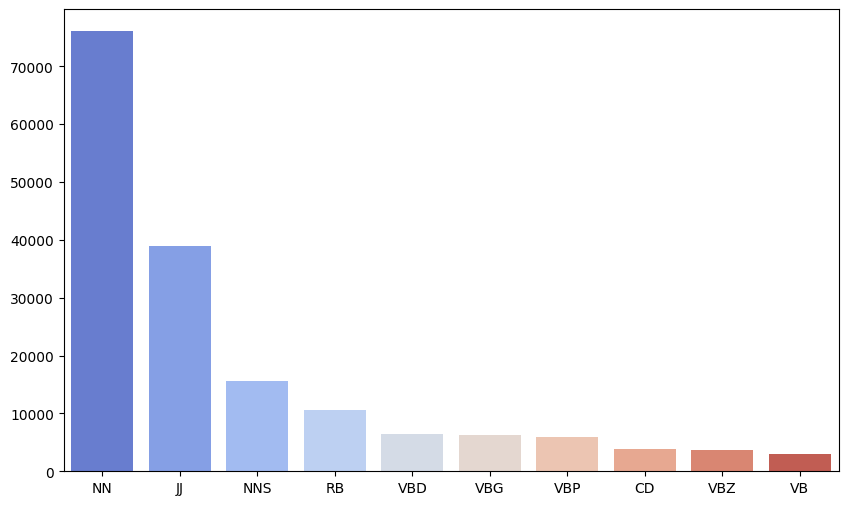

In [27]:
# VISUALIZE POST TAGGING

POST_TAG = dict(tagged)

freqs = {}

# COUNT FREQUENCY EVERY POST-TAG LABELS
for key, value in POST_TAG.items():
    if value not in freqs:
        freqs[value] = 1
    else:
        freqs[value] += 1

# GET TOP 20 POST-TAG LABELS
freqs_sort = sorted(freqs.items(), key= lambda x : x[1], reverse=True)[:10]

# SEPARATE DATA INTO X AND Y
keys = [data[0] for data in freqs_sort]
values = [data[1] for data in freqs_sort]

# VISUALIZE
plt.figure(figsize=(10,6))
sns.barplot(x = keys, y= values, palette='coolwarm')
plt.title('')

1. NN: Noun, Singular or Mass <br>
Definition: This tag is used for a singular noun or mass noun (uncountable nouns).<br>
Example: Singular noun: cat, book
Mass noun: water, sand
2. JJ: Adjective <br>
Definition: This tag is used for adjectives, which modify nouns. <br>
Example: big, beautiful, happy
3. NNS: Noun, Plural <br>
Definition: This tag is used for plural nouns.
Example: cats, books
4. RB: Adverb  <br>
Definition: This tag is used for adverbs, which modify verbs, adjectives, or other adverbs. <br>
Example: quickly, loudly, very
5. VBD: Verb, Past Tense  <br>
Definition: This tag is used for verbs in the past tense. <br>
Example: ran, ate, jumped
6. VBG: Verb, Gerund or Present Participle <br>
Definition: This tag is used for verbs in the gerund (verb + "ing") or present participle form (often used in continuous tenses). <br>
Example: running, eating, jumping
7. VBP: Verb, Non-3rd Person Singular Present  <br>
Definition: This tag is used for verbs in the present tense that are not in the third-person singular form (i.e., the subject is not "he," "she," or "it"). <br>
Example: run, eat, play (used with subjects like "I," "you," "we," or "they")
8. CD: Cardinal Number   <br>
Definition: This tag is used for numbers that represent quantity or a specific count. <br>
Example: one, two, hundred
9. VBZ: Verb, 3rd Person Singular Present  <br>
Definition: This tag is used for verbs in the present tense, specifically for third-person singular subjects (he, she, it). <br>
Example: runs, eats, plays
10. VB: Verb, Base Form  <br>
Definition: This tag is used for the base form of a verb, which is the infinitive form without "to." <br>
Example: run, eat, play (e.g., after modal verbs like "can," "will," "may")

# Feature Extraction

## Label Encoding

In [28]:
# CHANGE SENTIMENT LABELS TO NUMERIC

labels = []

for label in data['sentiment']:

    if label == 'positive':  # IF POSITIVE, THEN REPLACE WITH VALUE 1
        labels.append(1)
    else:
        labels.append(0)   # IF NEGATIVE, THEN REPLACE WITH VALUE 0


## Split Dataset

In [29]:
# TRAIN TEST SPLIT

# SPLIT DATA INTO TRAIN AND TEST
x_train , x_val, y_train, y_val = train_test_split(final_data, labels, test_size= 0.3, random_state=12, shuffle=True)

# SPLIT VAL DATA INTO VAL AND TEST
x_val, x_test, y_val, y_test = train_test_split(x_val, y_val, test_size= 0.2, random_state=12, shuffle=True)


# DISPLAY SOME INFORMATION
print(f'Train data have {len(x_train)} samples')
print(f'Validation data have {len(y_val)} samples')
print(f'Test data have {len(x_test)} samples')
print(f'Type : {type(x_train)}')

Train data have 34707 samples
Validation data have 11900 samples
Test data have 2975 samples
Type : <class 'list'>


In [30]:
# DISPLAY SOME DATA
print(x_train[1])

['disappoint', 'see', 'talented', 'actor', 'amitabh', 'bachchan', 'weak', 'role', 'especially', 'beyond', 'sensational', 'black', 'which', 'highly', 'recommend', 'one', 'line', 'film', 'states', 'sakar', 'mere', 'man', 'think', 'philosophy', 'director', 'ram', 'gopal', 'varma', 'credit', 'godfather', 'inspiration', 'movie', 'perhaps', 'problem', 'seem', 'like', 'badly', 'mangle', 'american', 'movie', 'set', 'india', 'leave', 'elbow', 'index', 'consider', 'seven', 'element', 'filmmaking', 'acting', 'continuity', 'plot', 'character', 'development', 'dialogue', 'artistry', 'production', 'sets', 'on', 'scale', 'high', '10', 'low', 'give', 'average', 'score', 'film', 'continuity', 'seem', 'high', 'maintain', 'violent', 'tone', 'infuse', 'drama', 'places', 'use', 'justice', 'outside', 'legal', 'system', 'motivation', 'however', 'seem', 'lack', 'emotion', 'connect', 'evil', 'organize', 'crime', 'act', 'rat', 'appear', 'weak', 'even', 'someone', 'beat', 'murdered', 'seem', 'hoohum', 'example',

## Text Vectorization

In [31]:
# FEATURE EXTRACTION USING TF-IDF

# CONVERT TOKEN INTO LIST OF STRINGS
x_train = [' '.join(text) for text in x_train]      # TEXT VECTORIZATION EXPECTS STRINGS TO FIT , NOT TOKEN
x_val   = [' '.join(text) for text in x_val]
x_test  = [' '.join(text) for text in x_test]


vectorizer = tf.keras.layers.TextVectorization(max_tokens= 50000, 
                                               standardize='lower_and_strip_punctuation',
                                               split='whitespace', 
                                               output_mode='int',
                                               output_sequence_length=700,
                                               pad_to_max_tokens=True,
                                               ngrams=1,
                                               )
vectorizer.adapt(x_train)


# TRANSFORM
vectorized_train = vectorizer(x_train)
vectorized_val   = vectorizer(x_val)
vectorized_test  = vectorizer(x_test)

#vectorized_train = np.array(vectorized_train)
#vectorized_val   = np.array(vectorized_val)
#vectorized_test  = np.array(vectorized_test)


In [32]:
# CONVERTING TO TENSOR DATASET
train_dataset = tf.data.Dataset.from_tensor_slices((vectorized_train, y_train)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((vectorized_val, y_val)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((vectorized_test, y_test)).batch(32)

# Model Development

## Perceptron Architecture with Global Pooling

In [33]:
# BUILD ARCHITECTURE

model_1 = tf.keras.Sequential(layers=[
    tf.keras.layers.Embedding(input_dim=50000, output_dim=24, mask_zero=True, input_length=700),
    tf.keras.layers.Dropout(rate=0.55),
    
    tf.keras.layers.GlobalAveragePooling1D(data_format='channels_last'),

    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

model_1.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ ?                           │     0 (unbuilt) │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
# CREATE CALLBACKS

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, verbose=1, restore_best_weights='True')

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1, min_lr=0.00001)

In [35]:
model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [36]:
train_1 = model_1.fit(train_dataset, epochs=12, verbose=1, validation_data= val_dataset, shuffle=True, callbacks=[early_stopping, reduce_lr])

Epoch 1/12
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7870 - loss: 0.6152 - val_accuracy: 0.8656 - val_loss: 0.3791 - learning_rate: 0.0010
Epoch 2/12
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8794 - loss: 0.3375 - val_accuracy: 0.8870 - val_loss: 0.2980 - learning_rate: 0.0010
Epoch 3/12
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9055 - loss: 0.2602 - val_accuracy: 0.8946 - val_loss: 0.2694 - learning_rate: 0.0010
Epoch 4/12
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9208 - loss: 0.2179 - val_accuracy: 0.8997 - val_loss: 0.2559 - learning_rate: 0.0010
Epoch 5/12
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9332 - loss: 0.1870 - val_accuracy: 0.9010 - val_loss: 0.2495 - learning_rate: 0.0010
Epoch 6/12
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9435 - loss: 0.1663 - val_accuracy: 0.9021 - val_loss: 0.2481 - learning_rate: 0.0010
Epoch 7/12
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9510 - l

## LSTM Architecture

In [37]:
# BUILD ARCHITECTURE
model_2 = tf.keras.Sequential(layers=[
    tf.keras.layers.Embedding(input_dim=50000, output_dim=10, mask_zero=True, input_length=700),
    tf.keras.layers.Dropout(0.45),
    
    tf.keras.layers.LSTM(units=50, return_sequences=True, dropout=0.5),
    tf.keras.layers.LSTM(units=25, return_sequences=False, dropout=0.6),

    tf.keras.layers.Dense(units=24, activation='linear', activity_regularizer= tf.keras.regularizers.l2(0.01), kernel_regularizer=tf.keras.regularizers.L2(0.015)),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [39]:
train_2 = model_2.fit(train_dataset, batch_size=70, epochs=8, verbose=1, validation_data= val_dataset, shuffle=True, callbacks=[early_stopping, reduce_lr])

Epoch 1/8
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.6827 - loss: 0.7033 - val_accuracy: 0.8552 - val_loss: 0.4287 - learning_rate: 0.0010
Epoch 2/8
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 34s 31ms/step - accuracy: 0.8720 - loss: 0.3833 - val_accuracy: 0.8690 - val_loss: 0.3548 - learning_rate: 0.0010
Epoch 3/8
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 33s 30ms/step - accuracy: 0.8990 - loss: 0.3145 - val_accuracy: 0.8773 - val_loss: 0.3554 - learning_rate: 0.0010
Epoch 4/8
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 33s 30ms/step - accuracy: 0.9175 - loss: 0.2700 - val_accuracy: 0.8834 - val_loss: 0.3458 - learning_rate: 0.0010
Epoch 5/8
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 34s 31ms/step - accuracy: 0.9235 - loss: 0.2495 - val_accuracy: 0.8831 - val_loss: 0.3442 - learning_rate: 0.0010
Epoch 6/8
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 33s 30ms/step - accuracy: 0.9309 - loss: 0.2267 - val_accuracy: 0.8855 - val_loss: 0.3350 - learning_rate: 0.0010
Epoch 6: early stopping
Restoring model weights from the end of the be

## Bidirectional LSTM

In [40]:
# BUILD ARCHITECTURE

model_3 = tf.keras.Sequential(layers=[
    tf.keras.layers.Embedding(input_dim=50000, output_dim=50, mask_zero=True, input_length=700),
    tf.keras.layers.Dropout(0.45),
    
    tf.keras.layers.Bidirectional(layer= tf.keras.layers.LSTM(units=54, return_sequences=True, dropout=0.35, kernel_regularizer=tf.keras.regularizers.l2(0.01))),
    tf.keras.layers.Bidirectional(layer= tf.keras.layers.LSTM(units=80, return_sequences=False, kernel_regularizer=tf.keras.regularizers.l1(0.00005))),
    tf.keras.layers.Dropout(0.45),
    
    tf.keras.layers.Dense(units=24, activation='selu', activity_regularizer= tf.keras.regularizers.l2(0.01), kernel_regularizer=tf.keras.regularizers.L2(0.015)),
    tf.keras.layers.Dropout(0.70),

    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
model_3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [43]:
train_3 = model_3.fit(train_dataset, epochs=3, batch_size=80, validation_data= val_dataset, verbose=1, callbacks=[early_stopping, reduce_lr], shuffle=True)

Epoch 1/3
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 68s 62ms/step - accuracy: 0.5055 - loss: 0.6934 - val_accuracy: 0.4996 - val_loss: 0.6934 - learning_rate: 5.0000e-04
Epoch 2/3
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 68s 62ms/step - accuracy: 0.5043 - loss: 0.6935 - val_accuracy: 0.4996 - val_loss: 0.6935 - learning_rate: 5.0000e-04
Epoch 3/3
1084/1085 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5051 - loss: 0.6935
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 68s 63ms/step - accuracy: 0.5051 - loss: 0.6935 - val_accuracy: 0.4996 - val_loss: 0.6935 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 1.


# Model Evaluation

## Evaluation for Perceptron with Global Pooling

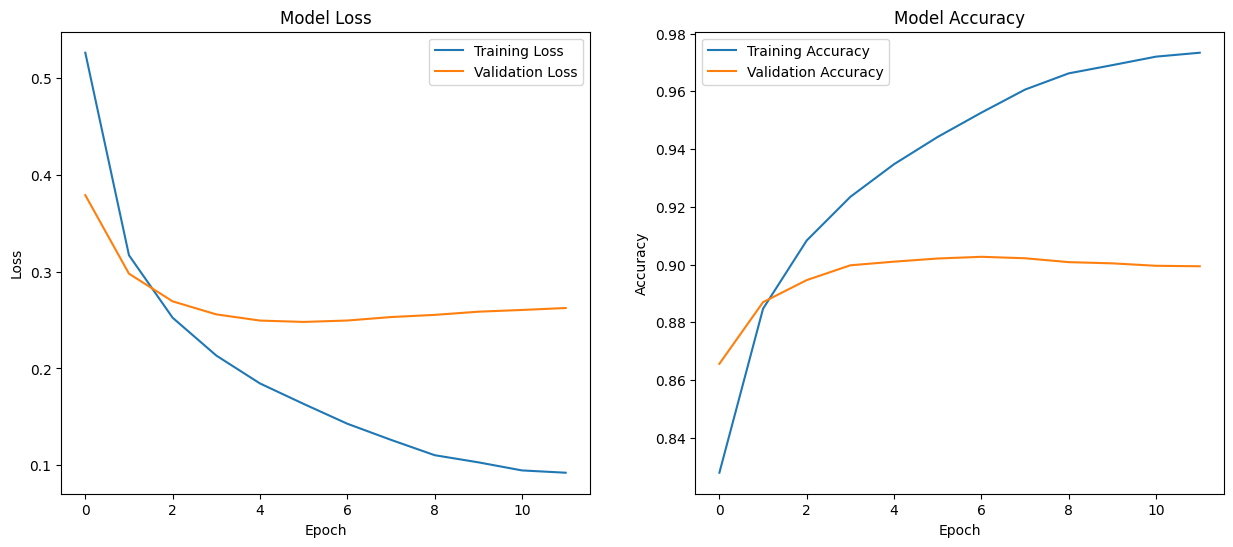

In [44]:
# SHOW METRICS EVALUATION

train_loss_1 = train_1.history['loss']
val_loss_1  = train_1.history['val_loss']

train_accuracy_1  = train_1.history['accuracy']
val_accuracy_1    = train_1.history['val_accuracy']

epoch = range(len(train_loss_1))

plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.plot(epoch, train_loss_1, label='Training Loss')
plt.plot(epoch, val_loss_1, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epoch, train_accuracy_1, label='Training Accuracy')
plt.plot(epoch, val_accuracy_1, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [45]:
# MODEL EVALUATION

# PREDICT TEST MODEL
y_prediction = model_1.predict(vectorized_test)
y_prediction_class = []

# IF VALUE MORE THAN 0.5 , THEN IT CATEGORIZED AS POSITIVE REVIEWS, OTHERWISE NEGATIVE REVIEWS
for value in y_prediction:  
    if value > 0.5:
        y_prediction_class.append(1)
    else:
        y_prediction_class.append(0)


# EVALUATION
accuracy  = accuracy_score(y_test, y_prediction_class)
precision = precision_score(y_test, y_prediction_class)
recall    = recall_score(y_test, y_prediction_class)
f1        = f1_score(y_test, y_prediction_class)

print(f'Accuracy  : {accuracy}')
print(f'Precision : {precision}')
print(f'recall    : {recall}')
print(f'F-1       : {f1}')

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy  : 0.9015126050420168
Precision : 0.8984375
recall    : 0.9096901779828609
F-1       : 0.9040288241074355


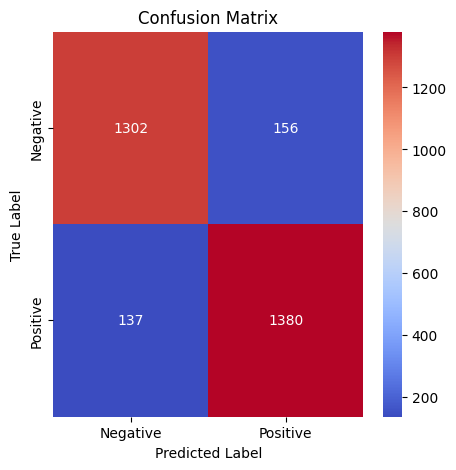

In [46]:
# PLOT CONFUSION MATRIX

matrix = confusion_matrix(y_test, y_prediction_class)

plt.figure(figsize=(5,5))

sns.heatmap(data= matrix, cmap='coolwarm', annot=True, fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Evaluation for LSTM Architecture

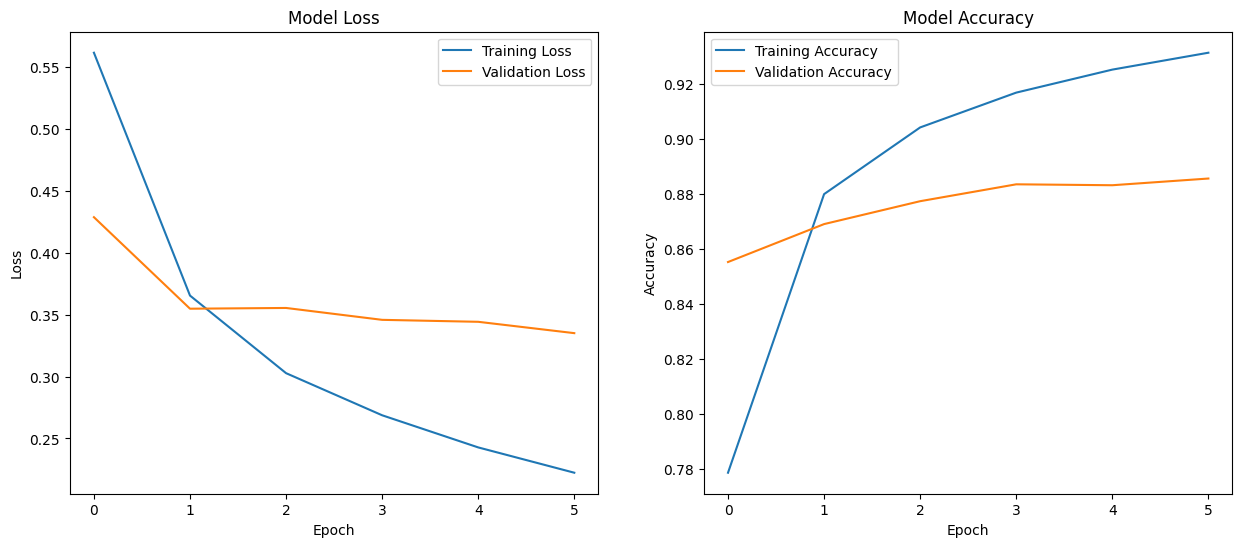

In [47]:
# SHOW METRICS EVALUATION

train_loss_2 = train_2.history['loss']
val_loss_2   = train_2.history['val_loss']

train_accuracy_2 = train_2.history['accuracy']
val_accuracy_2   = train_2.history['val_accuracy']

epoch = range(len(train_loss_2))

plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.plot(epoch, train_loss_2, label='Training Loss')
plt.plot(epoch, val_loss_2, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epoch, train_accuracy_2, label='Training Accuracy')
plt.plot(epoch, val_accuracy_2, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [48]:
# MODEL EVALUATION

# PREDICT TEST MODEL
y_prediction = model_2.predict(vectorized_test)
y_prediction_class = []

# IF VALUE MORE THAN 0.5 , THEN IT CATEGORIZED AS POSITIVE REVIEWS, OTHERWISE NEGATIVE REVIEWS
for value in y_prediction:  
    if value > 0.5:
        y_prediction_class.append(1)
    else:
        y_prediction_class.append(0)


# EVALUATION
accuracy  = accuracy_score(y_test, y_prediction_class)
precision = precision_score(y_test, y_prediction_class)
recall    = recall_score(y_test, y_prediction_class)
f1        = f1_score(y_test, y_prediction_class)

print(f'Accuracy  : {accuracy}')
print(f'Precision : {precision}')
print(f'recall    : {recall}')
print(f'F-1       : {f1}')

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
Accuracy  : 0.8561344537815126
Precision : 0.9042316258351893
recall    : 0.8029004614370469
F-1       : 0.8505586592178772


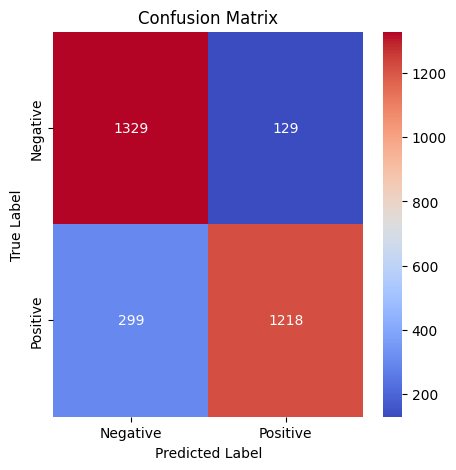

In [49]:
# PLOT CONFUSION MATRIX

matrix = confusion_matrix(y_test, y_prediction_class)

plt.figure(figsize=(5,5))

sns.heatmap(data= matrix, cmap='coolwarm', annot=True, fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Evaluation for Bidirectional LSTM

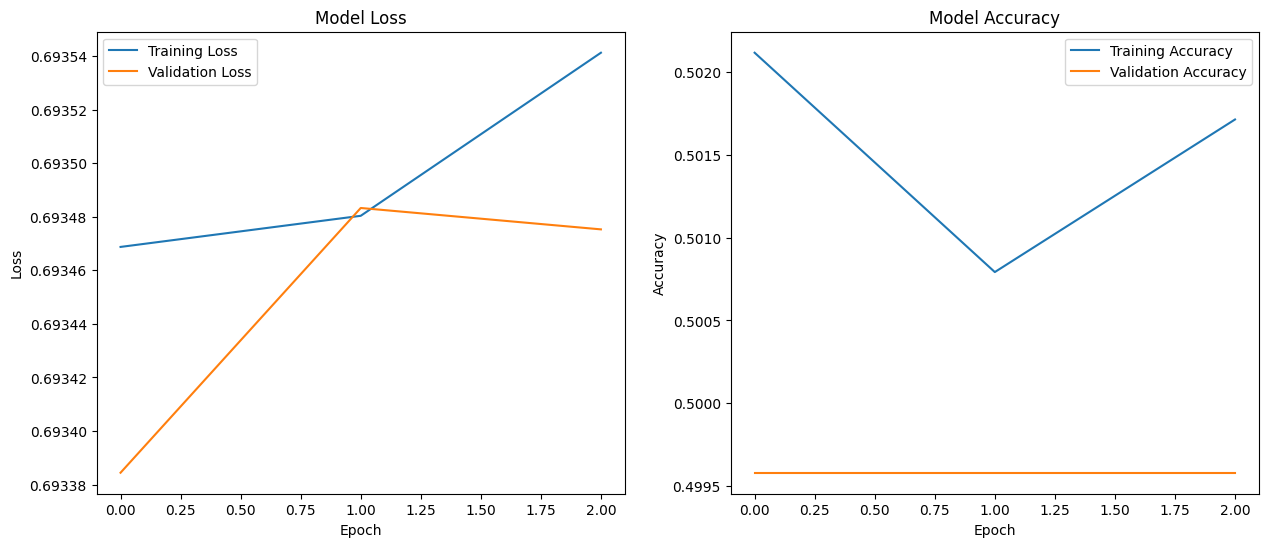

In [50]:
# SHOW METRICS EVALUATION

train_loss_3= train_3.history['loss']
val_loss_3  = train_3.history['val_loss']

train_accuracy_3 = train_3.history['accuracy']
val_accuracy_3 = train_3.history['val_accuracy']

epoch = range(len(train_loss_3))

plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.plot(epoch, train_loss_3, label='Training Loss')
plt.plot(epoch, val_loss_3, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epoch, train_accuracy_3, label='Training Accuracy')
plt.plot(epoch, val_accuracy_3, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [51]:
# MODEL EVALUATION

# PREDICT TEST MODEL
y_prediction = model_3.predict(vectorized_test)
y_prediction_class = []

# IF VALUE MORE THAN 0.5 , THEN IT CATEGORIZED AS POSITIVE REVIEWS, OTHERWISE NEGATIVE REVIEWS
for value in y_prediction:  
    if value > 0.5:
        y_prediction_class.append(1)
    else:
        y_prediction_class.append(0)


# EVALUATION
accuracy  = accuracy_score(y_test, y_prediction_class)
precision = precision_score(y_test, y_prediction_class)
recall    = recall_score(y_test, y_prediction_class)
f1        = f1_score(y_test, y_prediction_class)

print(f'Accuracy  : {accuracy}')
print(f'Precision : {precision}')
print(f'recall    : {recall}')
print(f'F-1       : {f1}')

93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
Accuracy  : 0.5099159663865547
Precision : 0.5099159663865547
recall    : 1.0
F-1       : 0.6754229741763135


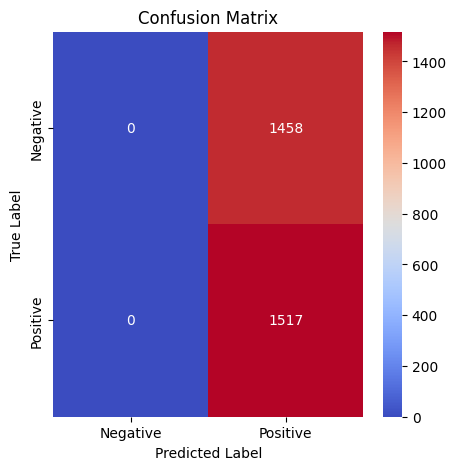

In [52]:
# PLOT CONFUSION MATRIX

matrix = confusion_matrix(y_test, y_prediction_class)

plt.figure(figsize=(5,5))

sns.heatmap(data= matrix, cmap='coolwarm', annot=True, fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Predict a New Reviews

In [53]:
# PREDICT A NEW REVIEWS
prompt = input('Enter a Reviews : ')


# REMOVE HTML TAG (if any)
clean_data = []
soup = BeautifulSoup(prompt, 'html.parser')  # DEFINE BEAUTIFUL SOUP
text = soup.get_text()     # GET ONLY TEXT FROM BEAUTIFULSOUP
clean_data.append(text)

# REMOVE STOPWORDS
cleaned_data = []
for review in clean_data:
    for word in review.split():
        cleaned_data.append(word)

# LEMMATIZATION
lemmatized_data = []
for review in cleaned_data:

    # LEMMATIZE ADJECTIVES TOKEN/WORD
    clean_text_1 = [lemma.lemmatize(word= word, pos='a') for word in review.split()]  
    clean_text_1 = ' '.join(clean_text_1)  # COMBINES EVERY WORD INTO SENTENCES

    # LEMMATIZE VERB TOKEN/WORD
    clean_text_2 = [lemma.lemmatize(word = word, pos='v') for word in clean_text_1.split()] 
    clean_text_2 = ' '.join(clean_text_2) # COMBINES EVERY WORD INTO SENTENCES

    # LEMMATIZE NOUN TOKEN/WORD
    clean_text_3 = [lemma.lemmatize(word= word, pos='n') for word in clean_text_2.split()] 
    clean_text_3 = ' '.join(clean_text_3)

    lemmatized_data.append(clean_text_3) 

# REMOVE PUNCTUATION
cleaned_token = []
for token in lemmatized_data:             # ITERATE OVER LIST OF TOKEN

    # ITERATE OVER EVERY TOKEN
    clean_token = re.sub(pattern= r'[^\w\s]', repl= '', string= token)  # REPLACE ALL PUNCTUATION INTO EMPTY STRING ''

    # PUSH NON EMPTY STRINGS AND REMOVE CHARACTERS THAT HAVE ONLY 1
    if len(clean_token) > 1 :
        cleaned_token.append(clean_token)

# TEXT VECTORIZATION
final_data = [' '.join(cleaned_token)]   
vectorized_data = vectorizer(final_data)

# PREDICTION (WE USED THE BEST MODEL TO PREDICT NEW REVIEWS)
y_prediction = model_1.predict(vectorized_data)

print(prompt)
if y_prediction > 0.5:
    print(f'\n\033[1mThis is Positive Reviews\033[0m')
else:
    print(f'\n\033[1mThis is Negative Reviews\033[0m')


Enter a Reviews :  this movy is bad


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
this movy is bad

This is Negative Reviews
